<a href="https://colab.research.google.com/github/Dass-19/LTSF/blob/main/LTSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
%matplotlib inline

In [36]:
np.random.seed(42)
torch.manual_seed(42)

# Resumen del paper

# Dataset

| Field | date | HUFL | HULL | MUFL | MULL | LUFL | LULL | OT |
| :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: |
| Description | The recorded **date** |**H**igh **U**se**F**ul **L**oad | **H**igh **U**se**L**ess **L**oad | **M**iddle **U**se**F**ul **L**oad | **M**iddle **U**se**L**ess **L**oad | **L**ow **U**se**F**ul **L**oad | **L**ow **U**se**L**ess **L**oad | **O**il **T**emperature (target) |

In [37]:
ETTh1 = pd.read_csv("https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv")

In [38]:
ETTh1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [39]:
ETTh1['date'] = pd.to_datetime(ETTh1['date'])

In [40]:
ETTh1.head(6)

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
5,2016-07-01 05:00:00,5.626,2.143,1.528,0.533,4.051,1.371,21.174000


In [41]:
ETTh1.isnull().sum()

,0
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


In [42]:
ETTh1.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


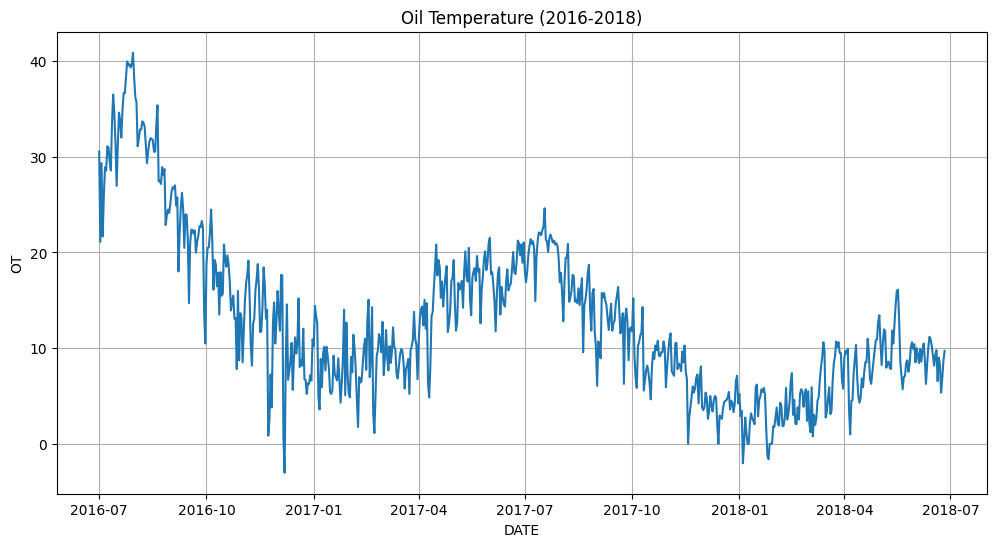

In [43]:
ETTh1_D = ETTh1.copy()
ETTh1_D.index = ETTh1_D.date
ETTh1_D.drop(columns=['date'], inplace=True)
ETTh1_D = ETTh1_D.asfreq('D').dropna()
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D.OT)
plt.title('Oil Temperature (2016-2018)')
plt.xlabel('DATE')
plt.ylabel('OT')
plt.grid()

In [44]:
ETTh1_D['OT_5'] = ETTh1_D['OT'].rolling(window=5).mean()
ETTh1_D['OT_15'] = ETTh1_D['OT'].rolling(window=15).mean()

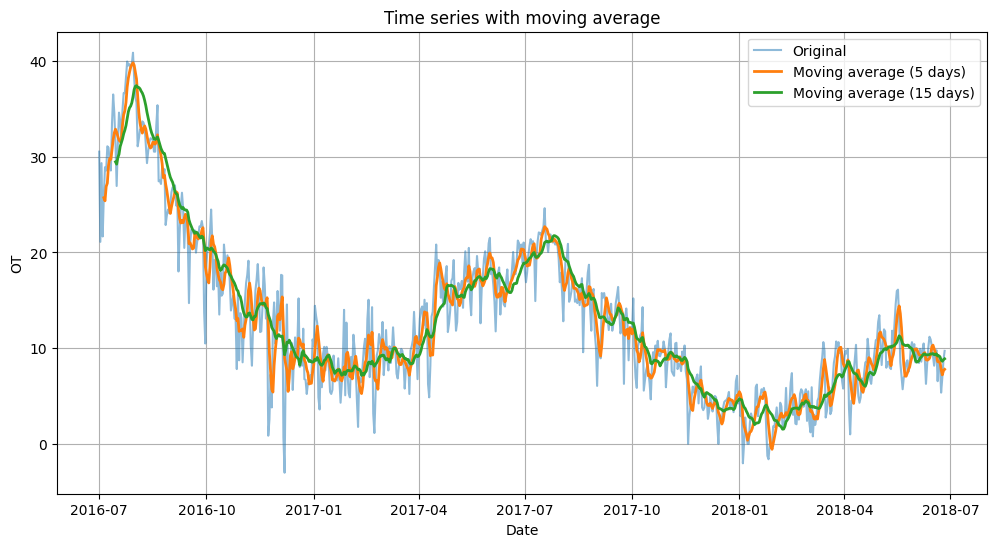

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D['OT'], label='Original', alpha=0.5)
plt.plot(ETTh1_D['OT_5'], label='Moving average (5 days)', linewidth=2)
plt.plot(ETTh1_D['OT_15'], label='Moving average (15 days)', linewidth=2)
plt.title('Time series with moving average')
plt.xlabel('Date')
plt.ylabel('OT')
plt.legend()
plt.grid()

In [46]:
ETTh1_D.head(15)

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,OT_5,OT_15
date,,,,,,,,,
2016-07-01,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,NaN,NaN
2016-07-02,5.224,3.081,2.701,1.315,2.437,1.523,21.104000,NaN,NaN
2016-07-03,10.382,5.425,7.604,2.310,2.955,1.675,29.334999,NaN,NaN
2016-07-04,9.913,5.894,6.254,2.630,3.015,1.858,21.667000,NaN,NaN
2016-07-05,11.989,5.626,8.777,2.949,3.198,1.980,25.958000,25.7190,NaN
2016-07-06,10.382,5.090,6.467,2.843,3.015,1.828,28.913000,25.3954,NaN
2016-07-07,12.592,5.157,9.204,2.310,2.772,1.614,28.561001,26.8868,NaN
2016-07-08,11.855,4.756,8.884,2.985,2.955,1.523,31.093000,27.2384,NaN
2016-07-09,14.602,5.961,11.300,3.340,3.259,1.767,30.952999,29.0956,NaN


In [47]:
decomposition = seasonal_decompose(ETTh1['OT'], model='additive', period=2160)

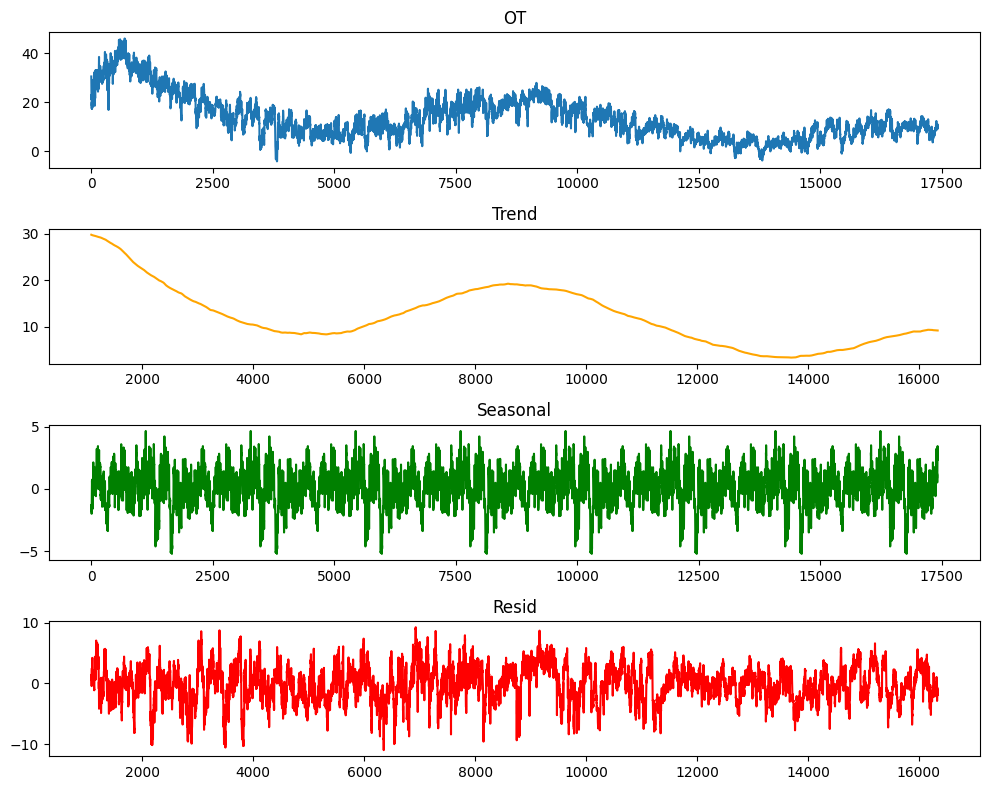

In [48]:
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(ETTh1['OT'])
plt.title("OT")

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, color='orange')
plt.title("Trend")

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, color='green')
plt.title("Seasonal")

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, color='red')
plt.title("Resid")

plt.tight_layout()
plt.show()

In [49]:
ETTh1.corr()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,1.000000,-0.166374,0.036580,-0.198914,-0.001046,0.162609,0.130340,-0.623583
HUFL,-0.166374,1.000000,0.114672,0.987355,0.066002,0.291418,0.023606,0.059916
HULL,0.036580,0.114672,1.000000,0.068817,0.930491,0.259487,0.377641,0.224354
MUFL,-0.198914,0.987355,0.068817,1.000000,0.046266,0.177491,-0.046519,0.050854
MULL,-0.001046,0.066002,0.930491,0.046266,1.000000,0.128607,0.069419,0.220004
LUFL,0.162609,0.291418,0.259487,0.177491,0.128607,1.000000,0.334563,0.118836
LULL,0.130340,0.023606,0.377641,-0.046519,0.069419,0.334563,1.000000,0.067455
OT,-0.623583,0.059916,0.224354,0.050854,0.220004,0.118836,0.067455,1.000000


# Implementación

In [50]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3, lr=5e-4):
        super().__init__()

        # Parámetros
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.lr = lr

        # Capas
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.drop = nn.Dropout(dropout)

        # Loss y optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(
            self.parameters(),
            lr=lr,
            weight_decay=1e-4
        )

        # ── Scheduler: baja el LR si val_loss no mejora en 3 épocas ──────────
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',       # queremos minimizar val_loss
            factor=0.5,      # LR *= 0.5 cuando se activa
            patience=15,      # espera 3 épocas sin mejora
            min_lr=1e-6,    # piso mínimo del LR
            #verbose=True     # imprime cuando reduce
        )

        # Tracking
        self.train_losses = []
        self.val_losses = []

        # Xavier_Uniform (Bueno para tanh/sigmoid)
        self._init_weights()

    def _init_weights(self):
        # Capa lineal
        nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
          # Inicializar Bias en 0
          nn.init.constant_(self.fc.bias, 0.0)

        # Capa LSTM
        for name, param in self.lstm.named_parameters():
          if 'weight_ih' in name:
            # Pesos de entrada a oculto
            nn.init.xavier_uniform_(param.data)

          elif 'weight_hh' in name:
            # Pesos de oculto a oculto
            nn.init.xavier_uniform_(param.data)

          elif 'bias' in name:
            # Inicializar Bias en 0
            nn.init.constant_(param.data, 0.0)
            # Forzamos el Bias de la forget gate en 1 para ayudar al gradiente
            n = param.size(0)
            param.data[n//4:n//2].fill_(1.0) # [i_gate, f_gate, g_gate, o_gate]

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        return: (batch, output_size)
        """
        # (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)

        # (batch, hidden_size)
        last_time_step = lstm_out[:, -1, :]

        # Dropout and linear layer
        out = self.fc(self.drop(last_time_step))

        return out

    def train_epoch(self, train_loader):
        """Entrena un epoch."""
        self.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.cuda()
            y_batch = y_batch.cuda()

            # Forward
            pred = self(X_batch)
            loss = self.criterion(pred, y_batch)

            # Backward
            self.optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=5.0)

            self.optimizer.step()
            epoch_loss += loss.item()

        return epoch_loss / len(train_loader)

    def validate(self, val_loader):
        """Valida el modelo."""
        self.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()

                pred = self(X_batch)
                loss = self.criterion(pred, y_batch)
                val_loss += loss.item()

        return val_loss / len(val_loader)

    def fit(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32, verbose=True, patience=15):
        """
        Entrena el modelo.

        Args:
            X_train: (n_samples, seq_len, input_size)
            y_train: (n_samples, output_size)
            X_val: (n_samples, seq_len, input_size)
            y_val: (n_samples, output_size)
            epochs: número de epochs
            batch_size: tamaño del batch
            verbose: print info cada epoch
        """
        # Crear dataloaders
        train_data = TensorDataset(
            torch.from_numpy(X_train).float(),
            torch.from_numpy(y_train).float()
            )
        val_data = TensorDataset(
            torch.from_numpy(X_val).float(),
            torch.from_numpy(y_val).float()
            )

        train_loader = DataLoader(
            train_data,
            batch_size=batch_size,
            shuffle=True
            )
        val_loader = DataLoader(
            val_data,
            batch_size=batch_size
            )

        # Mover modelo a GPU
        self.cuda()

        print("Training parameters: \n")
        print(f"Epochs: {epochs}")
        print(f"Batch size: {batch_size}")
        print(f"Learning rate: {self.lr}")
        print(f"Loss: MSELoss")
        print(f"Optimizer: Adam")
        print(f"Gradient clipping: max_norm=5.0\n")
        #--- Variables del Early Stopping ---
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_weights = None # Guardaremos los pesos óptimos en memoria RAM

        # Reiniciar historiales por si se re-entrena
        self.train_losses = []
        self.val_losses = []

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)

            # Guardar histórico para graficar después
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            if verbose:
                print(f"epoch {epoch+1:3d}/{epochs} | train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f}")

            # --- Lógica de Early Stopping ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Hacemos una copia profunda de los mejores pesos en la RAM
                best_model_weights = {k: v.cpu().clone() for k, v in self.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\n[Early Stopping] ¡Entrenamiento interrumpido en la época {epoch+1}!")
                    print(f"[Early Stopping] La pérdida de validación no mejoró durante {patience} épocas.")
                    break

        # Al salir del bucle, restauramos los pesos del mejor punto histórico
        if best_model_weights is not None:
            self.load_state_dict(best_model_weights)
            self.cuda()  # Lo devolvemos a la GPU listo para predecir
            print(f"-> ¡Éxito! Cargados los mejores pesos (Val Loss Mínimo alcanzado: {best_val_loss:.6f})\n")

    def predict(self, X):
        """
        Predice sobre datos nuevos.

        Args:
            X: (n_samples, seq_len, input_size)

        Returns:
            predicciones: (n_samples, output_size)
        """
        self.eval()
        X = torch.from_numpy(X).float().cuda()

        with torch.no_grad():
            pred = self(X)

        return pred.cpu().numpy()

    def plot_losses(self):
        """Grafica train vs val loss."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss', linewidth=2)
        plt.plot(self.val_losses, label='Val Loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Entrenamiento y evaluación

In [51]:
TRAIN_SIZE = 0.8
TARGET = 'OT'
EPOCHS = 50
BATCH_SIZE = 32
LSTM_LAYERS= 2
HIDDEN_SIZE = 256

In [52]:
ETTh1 = ETTh1.sort_values(by='date')
# Global timestamps
# ── Después: Codificación cíclica Sin/Cos
# La hora 23 y la hora 0 ahora son "cercanas" para la red
ETTh1['HOUR_SIN']        = np.sin(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['HOUR_COS']        = np.cos(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['DOW_SIN']         = np.sin(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['DOW_COS']         = np.cos(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['MONTH_SIN']       = np.sin(2 * np.pi * ETTh1['date'].dt.month       / 12)
ETTh1['MONTH_COS']       = np.cos(2 * np.pi * ETTh1['date'].dt.month       / 12)

In [53]:
features = [
    'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL',
    'HOUR_SIN', 'HOUR_COS',   # reemplaza HOUR
    'DOW_SIN',  'DOW_COS',    # reemplaza DAY_OF_WEEK
    'MONTH_SIN', 'MONTH_COS'  # reemplaza MONTH
    ]
cols = features + [TARGET]

data = ETTh1[cols].values.astype(np.float32)

split = int(TRAIN_SIZE * len(data))
train_data = data[:split]
val_data = data[split:]

train_min = train_data.min(axis=0)
train_max = train_data.max(axis=0)
denominator = np.where((train_max - train_min) == 0, 1, (train_max - train_min))

train_data_scaled = (train_data - train_min) / denominator
val_data_scaled = (val_data - train_min) / denominator

In [54]:
def create_sequences_multivariate(data, horizon, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i : i+seq_len, :-1])
        y.append(data[i+seq_len : i+seq_len+horizon, -1])

    return np.array(X), np.array(y)

## Horizonte `96`

LSTM(
  (lstm): LSTM(12, 256, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=256, out_features=96, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.001
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.026247 | val_loss: 0.039607
epoch   2/50 | train_loss: 0.011962 | val_loss: 0.016401
epoch   3/50 | train_loss: 0.009059 | val_loss: 0.030898
epoch   4/50 | train_loss: 0.009238 | val_loss: 0.017915
epoch   5/50 | train_loss: 0.007107 | val_loss: 0.024900
epoch   6/50 | train_loss: 0.008096 | val_loss: 0.024399
epoch   7/50 | train_loss: 0.008747 | val_loss: 0.018822
epoch   8/50 | train_loss: 0.005861 | val_loss: 0.021276
epoch   9/50 | train_loss: 0.005807 | val_loss: 0.015444
epoch  10/50 | train_loss: 0.005890 | val_loss: 0.016205
epoch  11/50 | train_loss: 0.005473 | val_loss: 0.014954
epoch  12/50 | train_loss: 0.005304 | 

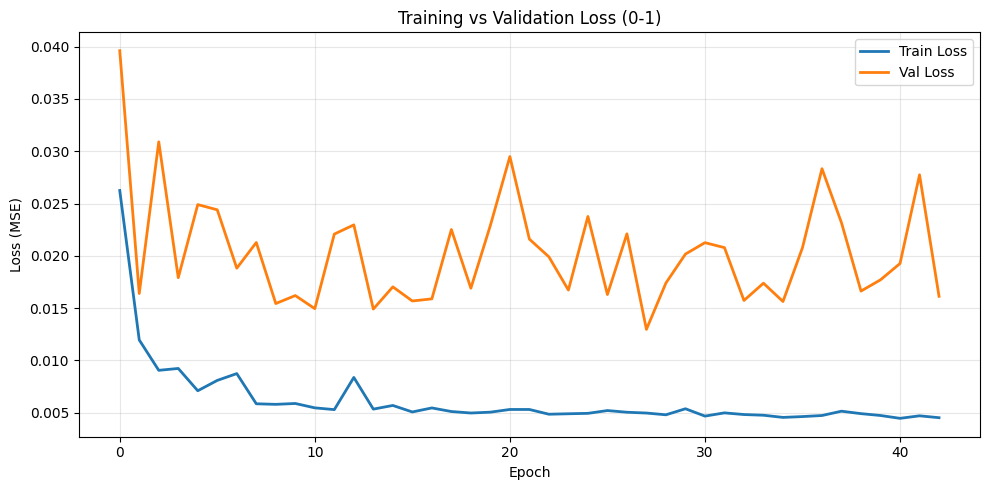


MSE: 32.266422 | RMSE: 5.680354 | MAE: 4.846467



In [55]:
X_train, y_train = create_sequences_multivariate(train_data_scaled, horizon=96, seq_len=120)

X_val, y_val = create_sequences_multivariate(val_data_scaled, horizon=96, seq_len=120)

model = LSTM(
    input_size=len(features),
    hidden_size=HIDDEN_SIZE,
    num_layers=LSTM_LAYERS,
    output_size=96,
    dropout=0.4,
    lr=0.001
    )

print(model)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=15
    )

model.plot_losses()

y_pred = model.predict(X_val)

min_ot = train_min[-1]
denom_ot = denominator[-1]
y_val_original = y_val * denom_ot + min_ot
y_pred_original = y_pred * denom_ot + min_ot
mse = mean_squared_error(y_val_original, y_pred_original)
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"\nMSE: {mse:.6f} | RMSE: {rmse:.6f} | MAE: {mae:.6f}\n")


## Horizonte `336`

LSTM(
  (lstm): LSTM(12, 256, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=256, out_features=336, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.0005
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.024670 | val_loss: 0.029997
epoch   2/50 | train_loss: 0.011160 | val_loss: 0.039682
epoch   3/50 | train_loss: 0.011312 | val_loss: 0.035852
epoch   4/50 | train_loss: 0.011472 | val_loss: 0.040666
epoch   5/50 | train_loss: 0.009648 | val_loss: 0.030668
epoch   6/50 | train_loss: 0.008726 | val_loss: 0.020896
epoch   7/50 | train_loss: 0.009201 | val_loss: 0.025776
epoch   8/50 | train_loss: 0.008340 | val_loss: 0.020095
epoch   9/50 | train_loss: 0.006601 | val_loss: 0.021542
epoch  10/50 | train_loss: 0.006173 | val_loss: 0.020008
epoch  11/50 | train_loss: 0.007868 | val_loss: 0.025449
epoch  12/50 | train_loss: 0.007107 

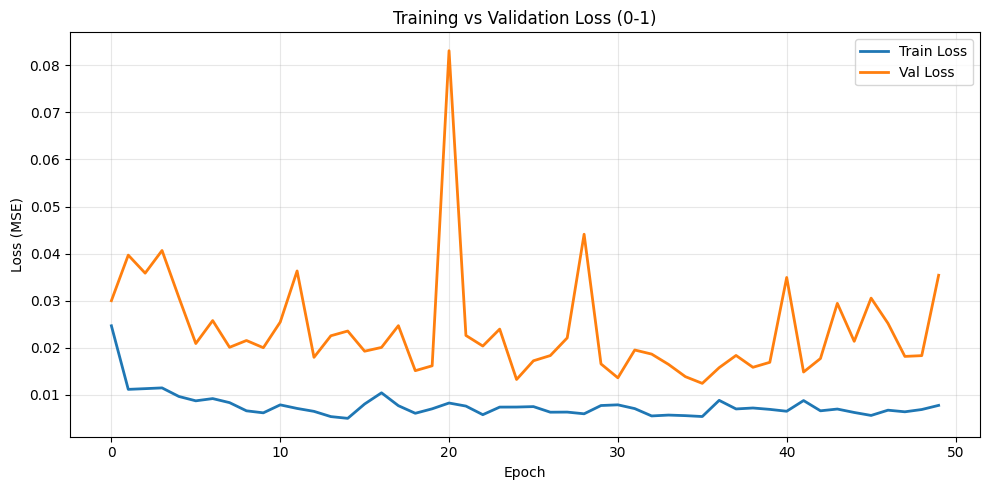


MSE: 31.135571 | RMSE: 5.579926 | MAE: 4.797313



In [56]:
X_train, y_train = create_sequences_multivariate(train_data_scaled, horizon=336, seq_len=336)

X_val, y_val = create_sequences_multivariate(val_data_scaled, horizon=336, seq_len=336)

model = LSTM(
    input_size=len(features),
    hidden_size=HIDDEN_SIZE,
    num_layers=LSTM_LAYERS,
    output_size=336,
    dropout=0.4,
    lr=5e-4
    )

print(model)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=15
    )

model.plot_losses()

y_pred = model.predict(X_val)

min_ot = train_min[-1]
denom_ot = denominator[-1]
y_val_original = y_val * denom_ot + min_ot
y_pred_original = y_pred * denom_ot + min_ot
mse = mean_squared_error(y_val_original, y_pred_original)
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"\nMSE: {mse:.6f} | RMSE: {rmse:.6f} | MAE: {mae:.6f}\n")


## Modelamiento yo

In [57]:
TRAIN_SIZE = 0.8
TARGET = 'OT'

HORIZONS = [96, 336]
SEQ_LEN = 120 # Look-back window

EPOCHS = 50
DROPOUT = 0.4
LR = 5e-4
BATCH_SIZE = 32
LSTM_LAYERS= 2
HIDDEN_SIZE = 256

# SEQ_LEN adaptivo por horizonte
SEQ_LEN_MAP = {96: 168, 336: 336}

In [58]:
ETTh1 = ETTh1.sort_values(by='date')
# Global timestamps
# ── Después: Codificación cíclica Sin/Cos
# La hora 23 y la hora 0 ahora son "cercanas" para la red
ETTh1['HOUR_SIN']        = np.sin(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['HOUR_COS']        = np.cos(2 * np.pi * ETTh1['date'].dt.hour        / 24)
ETTh1['DOW_SIN']         = np.sin(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['DOW_COS']         = np.cos(2 * np.pi * ETTh1['date'].dt.dayofweek  / 7)
ETTh1['MONTH_SIN']       = np.sin(2 * np.pi * ETTh1['date'].dt.month       / 12)
ETTh1['MONTH_COS']       = np.cos(2 * np.pi * ETTh1['date'].dt.month       / 12)

In [59]:
features = [
    'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL',
    'HOUR_SIN', 'HOUR_COS',   # reemplaza HOUR
    'DOW_SIN',  'DOW_COS',    # reemplaza DAY_OF_WEEK
    'MONTH_SIN', 'MONTH_COS'  # reemplaza MONTH
    ]
cols = features + [TARGET]

data = ETTh1[cols].values.astype(np.float32)

split = int(TRAIN_SIZE * len(data))
train_data = data[:split]
val_data = data[split:]

train_min = train_data.min(axis=0)
train_max = train_data.max(axis=0)
denominator = np.where((train_max - train_min) == 0, 1, (train_max - train_min))

train_data_scaled = (train_data - train_min) / denominator
val_data_scaled = (val_data - train_min) / denominator

In [60]:
def create_sequences_multivariate(data, horizon, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i : i+seq_len, :-1])
        y.append(data[i+seq_len : i+seq_len+horizon, -1])

    return np.array(X), np.array(y)

Horizon: 96 | SEQ_LEN: 168

LSTM(
  (lstm): LSTM(12, 256, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=256, out_features=96, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.0005
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.027295 | val_loss: 0.019996
epoch   2/50 | train_loss: 0.011302 | val_loss: 0.021132
epoch   3/50 | train_loss: 0.008156 | val_loss: 0.025136
epoch   4/50 | train_loss: 0.007011 | val_loss: 0.027888
epoch   5/50 | train_loss: 0.007453 | val_loss: 0.018726
epoch   6/50 | train_loss: 0.005893 | val_loss: 0.016405
epoch   7/50 | train_loss: 0.005850 | val_loss: 0.020015
epoch   8/50 | train_loss: 0.005091 | val_loss: 0.019284
epoch   9/50 | train_loss: 0.005002 | val_loss: 0.018050
epoch  10/50 | train_loss: 0.004999 | val_loss: 0.017450
epoch  11/50 | train_loss: 0.004893 | val_loss: 0.017321
epoch  12

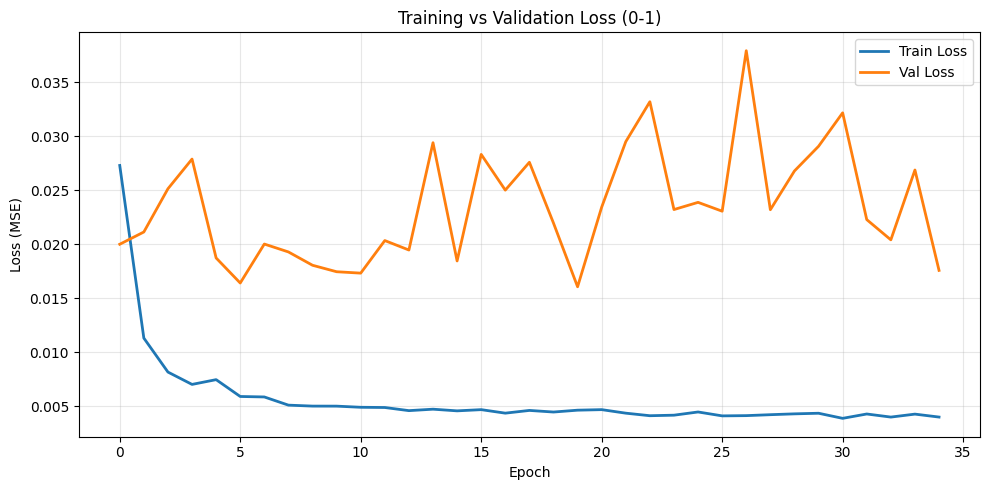


MSE: 40.004486 | RMSE: 6.324910 | MAE: 5.450663

Horizon: 336 | SEQ_LEN: 336

LSTM(
  (lstm): LSTM(12, 256, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=256, out_features=336, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
  (criterion): MSELoss()
)
Training parameters: 

Epochs: 50
Batch size: 32
Learning rate: 0.0005
Loss: MSELoss
Optimizer: Adam
Gradient clipping: max_norm=5.0

epoch   1/50 | train_loss: 0.023381 | val_loss: 0.011384
epoch   2/50 | train_loss: 0.009901 | val_loss: 0.008025
epoch   3/50 | train_loss: 0.008676 | val_loss: 0.018085
epoch   4/50 | train_loss: 0.006275 | val_loss: 0.021395
epoch   5/50 | train_loss: 0.006610 | val_loss: 0.021903
epoch   6/50 | train_loss: 0.006012 | val_loss: 0.011974
epoch   7/50 | train_loss: 0.005930 | val_loss: 0.016043
epoch   8/50 | train_loss: 0.005343 | val_loss: 0.016412
epoch   9/50 | train_loss: 0.005495 | val_loss: 0.015065
epoch  10/50 | train_loss: 0.006084 | val_loss: 0.017996
epoch  11/50 |

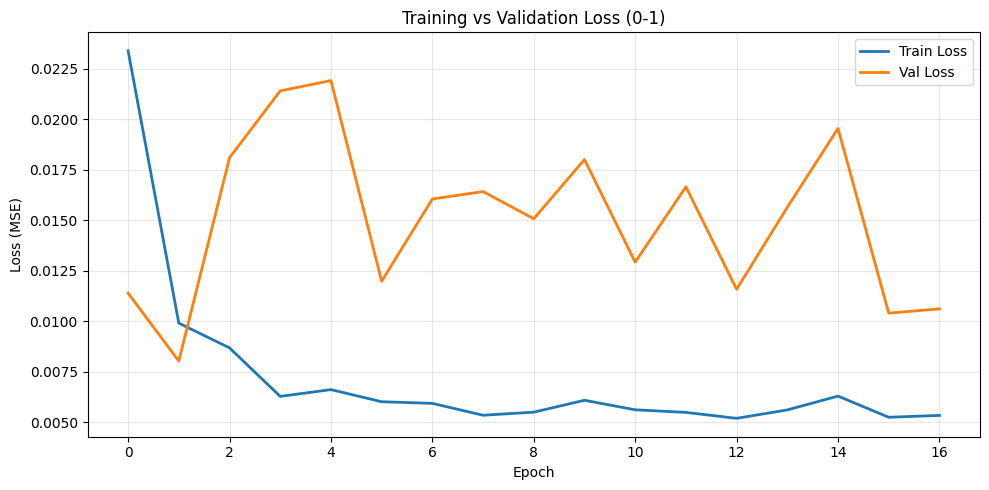


MSE: 19.779995 | RMSE: 4.447471 | MAE: 3.622044



In [61]:
for h in HORIZONS:
  seq_len = SEQ_LEN_MAP[h]                          # ← adaptivo
  print(f"Horizon: {h} | SEQ_LEN: {seq_len}\n")
  X_train, y_train = create_sequences_multivariate(
      train_data_scaled,
      horizon=h,
      seq_len=SEQ_LEN
      )

  X_val, y_val = create_sequences_multivariate(
      val_data_scaled,
      horizon=h,
      seq_len=SEQ_LEN
      )

  model = LSTM(
      input_size=len(features),
      hidden_size=HIDDEN_SIZE,
      num_layers=LSTM_LAYERS,
      output_size=h,
      dropout=DROPOUT,
      lr=LR
      )

  print(model)

  model.fit(
      X_train, y_train,
      X_val, y_val,
      epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      patience = 15
      )

  model.plot_losses()

  y_pred = model.predict(X_val)

  # Desnormalización de métricas
  min_ot = train_min[-1]
  denom_ot = denominator[-1]
  y_val_original = y_val * denom_ot + min_ot
  y_pred_original = y_pred * denom_ot + min_ot

  mse = mean_squared_error(y_val_original, y_pred_original)
  mae = mean_absolute_error(y_val_original, y_pred_original)
  rmse = np.sqrt(mse)

  print(f"\nMSE: {mse:.6f} | RMSE: {rmse:.6f} | MAE: {mae:.6f}\n")

Baseline del Paper:


```https://arxiv.org/abs/2205.13504```
- Multivariate Forecasting

| Methods | Metric | 96 | 336 |
| :--- | :--- | :--- | :--- |
| **Linear** | MSE | 0.375 | 0.479 |
| | MAE | 0.397 | 0.476 |
| **NLinear** | MSE | 0.374 | 0.429 |
| | MAE | 0.394 | 0.427 |
| **DLinear** | MSE | 0.375 | 0.439 |
| | MAE | 0.399 | 0.443 |

 # Análisis crítico

# Conclusiones